# Detail-Auswertung

## Imports and constants

In [2]:
# Imports / global contants

# csv Dateien sind im Verzeichnis ../data zu finden

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import numpy as np
import seaborn as sns
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks

from pandas.plotting import parallel_coordinates

timeFormat = "%Y-%m-%dT%H:%M:%S.%fZ"

export = "../export/"
export_img = "../export/img/"

path = "../data/"

In [46]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy.csv', sep=";")

# retrieve labels for results
states = df_cleaned[
    ((df_cleaned["posX"] == " COMPLETED") | 
    (df_cleaned["posX"] == " FAILED") | 
    (df_cleaned["posX"] == " TERMINATED") | 
    (df_cleaned["posX"] == " START"))
  ]

# insert labels
df_cleaned["Result"] = states["posX"]

# fill (bottom-up)
df_cleaned["Result"].fillna(method='bfill', inplace=True)

# drop na (end)
df_cleaned = df_cleaned.dropna(subset=["Result"])

# drop start (between trials)
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned["Result"] == " START") & (df_cleaned["posX"] != " START")].index)

df_cleaned["Block"] = (df_cleaned["TaskNo"] / 18).apply(np.ceil).astype(int)
df_cleaned["TaskNo"] = (df_cleaned["TaskNo"] - ((df_cleaned["Block"] - 1) * 18)).astype(int)
df_cleaned["TrialIdx"] = df_cleaned["TrialIdx"].astype(int)   
df_cleaned["TargetLayers"] = df_cleaned["TargetLayers"].str.split(",")
df_cleaned["Target"] = df_cleaned.apply(lambda item: item["TargetLayers"][item["TrialIdx"]], axis = 1).astype(int)
df_cleaned["Target_Relative"] = df_cleaned["Target"].astype(float) / df_cleaned["LayerCount"].astype(float)

df_cleaned.reset_index(inplace=True)

df_cleaned.rename(columns={ df_cleaned.columns[0]:"SampleIdx_global", df_cleaned.columns[1]:"SampleIdx_Proband", "TrialIdx":"Trial", "LayerCount":"NumLayers", "TaskNo":"Task" }, inplace=True)

display(df_cleaned)

df_cleaned.to_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep= ";")



,SampleIdx_global,SampleIdx_Proband,DateTime,State,mappingMethod,Task,TargetLayers,NumLayers,Trial,posX,...,posZ,TimeStamp,iteractionType,currentLayer,Proband,shifted,Result,Block,Target,Target_Relative
0,135,135,2021-05-10T12:13:56.584Z,VIEW,direct,1,"[4, 5, 3, 1, 2]",6,0,START,...,NaN,NaN,NaN,NaN,1,1.0,START,1,4,0.666667
1,136,136,2021-05-10T12:13:56.602Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
2,137,137,2021-05-10T12:13:56.633Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
3,138,138,2021-05-10T12:13:56.676Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
4,139,139,2021-05-10T12:13:56.697Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535230,2360983,90204,2021-06-30T12:37:15.245Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.252979726,...,-0.9999999,637606606352421800,1,6,24,54.0,FAILED,3,1,0.166667
1535231,2360984,90205,2021-06-30T12:37:15.291Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606352861800,1,6,24,54.0,FAILED,3,1,0.166667
1535232,2360985,90206,2021-06-30T12:37:15.323Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606353161900,1,6,24,54.0,FAILED,3,1,0.166667
1535233,2360986,90207,2021-06-30T12:37:15.361Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.240411818,...,-0.9999999,637606606353551700,1,6,24,54.0,FAILED,3,1,0.166667


---

## helper function to get layer borders

---

In [58]:
def getLayerBorders(layers, mapping):
    layerdata = pd.read_csv(rf'{path}meta/depthlayers.csv', sep=";")

    layer = layerdata[(layerdata.iloc[:,0] == layers) & (layerdata.iloc[:, 1] == mapping)]

    return np.array(layer.iloc[:,3].str.split("|").iloc[0], float)

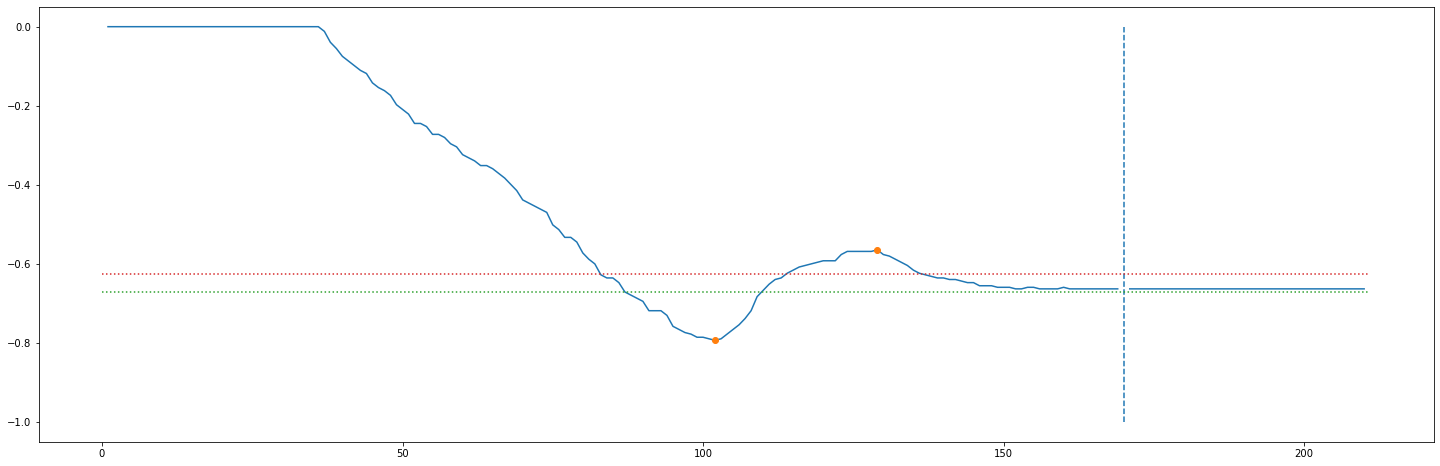

In [90]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

proband = 15
task = 4
block = 2
trial = 0

exp_data = df_cleaned[(df_cleaned["Proband"] == proband) & (df_cleaned["Task"] == task) & (df_cleaned["Block"] == block) & (df_cleaned["Trial"] == trial)].reset_index(drop=True)

z_data = exp_data["posZ"].replace("-", 0).astype(float)

target = exp_data["Target"][0]

borders = getLayerBorders(exp_data["NumLayers"][0], exp_data["mappingMethod"][0])

miny = [-borders[target+1]]*len(z_data)
maxy = [-borders[target]]*len(z_data)

hold = exp_data[exp_data["posX"] == " HOLD"].index

ex_max, _ = find_peaks(z_data, prominence=0.05)
ex_min, _ = find_peaks(-z_data, prominence=0.05)

peaks = np.concatenate([ex_max,ex_min])

fig,ax = plt.subplots(figsize=(25,8))

ax.plot(exp_data.index, z_data, label='Depth')
ax.plot(peaks, z_data[peaks], "o")

plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

ax.plot(miny, linestyle=":")
ax.plot(maxy, linestyle=":")

plt.show()

## extract all graphs for specific layer / target / mapping config

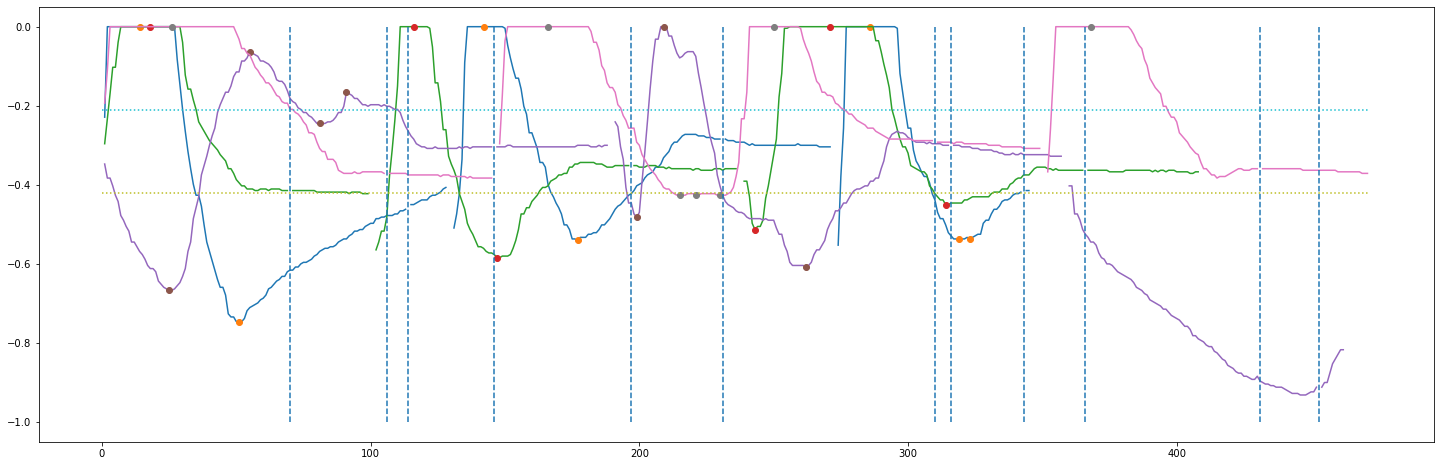

In [142]:
num_layers = 6
target = 1
mapping = " densening"

exp_data_complete = df_cleaned[(df_cleaned["mappingMethod"] == mapping) & (df_cleaned["Target"] == target) & (df_cleaned["NumLayers"] == num_layers)].reset_index(drop=True).groupby(["Proband"])

borders = getLayerBorders(num_layers, mapping)

fig,ax = plt.subplots(figsize=(25,8))

z_data = pd.DataFrame()
peaks = pd.DataFrame()
hold = []

i = 0

for name, group in exp_data_complete:

     if i > 3:
          break
     
     norm = group.reset_index(drop=True)

     newData = norm["posZ"].replace("-", 0).astype(float)
     z_data = pd.concat([z_data, newData], axis=1, ignore_index=True)

     ax.plot(newData.index, newData, label=name)

     ex_max, _ = find_peaks(newData, prominence=0.05)
     ex_min, _ = find_peaks(-newData, prominence=0.05)

     newPeaks = np.concatenate([ex_max,ex_min])
     peaks = pd.concat([peaks, pd.DataFrame(newPeaks)], axis=1, ignore_index=True)
     
     ax.plot(newPeaks, newData[newPeaks], "o")

     newHold = np.array(norm[norm["posX"] == " HOLD"].index)

     hold = np.concatenate([hold, newHold])

     i += 1

plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

miny = [-borders[target+1]]*len(z_data)
maxy = [-borders[target]]*len(z_data)

ax.plot(miny, linestyle=":")
ax.plot(maxy, linestyle=":")

plt.savefig(rf'{export_img}allInteractions_{target}-{num_layers}_{mapping}.png')
plt.savefig(rf'{export_img}allInteractions_{target}-{num_layers}_{mapping}.svg')
plt.show()

